In [1]:
import torch
import torch.nn as nn
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import cv2
import timm

# ---- Load the saved model ----
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using: {device}")

checkpoint = torch.load("../model/best_model.pth", map_location=device)

CLASS_NAMES = checkpoint["class_names"]

# Rebuild the same model architecture
model = timm.create_model("efficientnet_b3", pretrained=False, num_classes=120)
model.load_state_dict(checkpoint["model_state"])
model = model.to(device)
model.eval()

print("✅ Model loaded successfully!")
print(f"Total breeds: {len(CLASS_NAMES)}")

d:\DogBreedAI\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using: cpu
✅ Model loaded successfully!
Total breeds: 120


In [2]:
class GradCAM:
    def __init__(self, model):
        self.model      = model
        self.gradients  = None
        self.activations = None

        # Hook into the last conv layer of EfficientNet
        # This is the layer we want to visualize
        target_layer = model.blocks[-1]

        # Forward hook — saves the layer output (activations)
        target_layer.register_forward_hook(self._save_activation)

        # Backward hook — saves the gradients
        target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, input, output):
        # Called automatically during forward pass
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        # Called automatically during backward pass
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx):
        # Forward pass
        output = self.model(input_tensor)

        # Clear previous gradients
        self.model.zero_grad()

        # Backward pass for the predicted class only
        score = output[0, class_idx]
        score.backward()

        # Average the gradients across channels
        weights = self.gradients.mean(dim=(2, 3), keepdim=True)

        # Multiply weights with activations to get heatmap
        heatmap = (weights * self.activations).sum(dim=1).squeeze()

        # Keep only positive values
        heatmap = torch.relu(heatmap)

        # Normalize between 0 and 1
        heatmap = heatmap - heatmap.min()
        heatmap = heatmap / (heatmap.max() + 1e-8)

        return heatmap.cpu().numpy()

In [3]:
def overlay_heatmap(original_image, heatmap):
    # Resize heatmap to match original image size
    h, w   = np.array(original_image).shape[:2]
    heatmap = cv2.resize(heatmap, (w, h))

    # Convert heatmap to color (blue=low, red=high attention)
    heatmap_color = cv2.applyColorMap(
        np.uint8(255 * heatmap), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

    # Blend heatmap with original image
    original_array = np.array(original_image)
    overlaid       = cv2.addWeighted(original_array, 0.6, heatmap_color, 0.4, 0)

    return overlaid

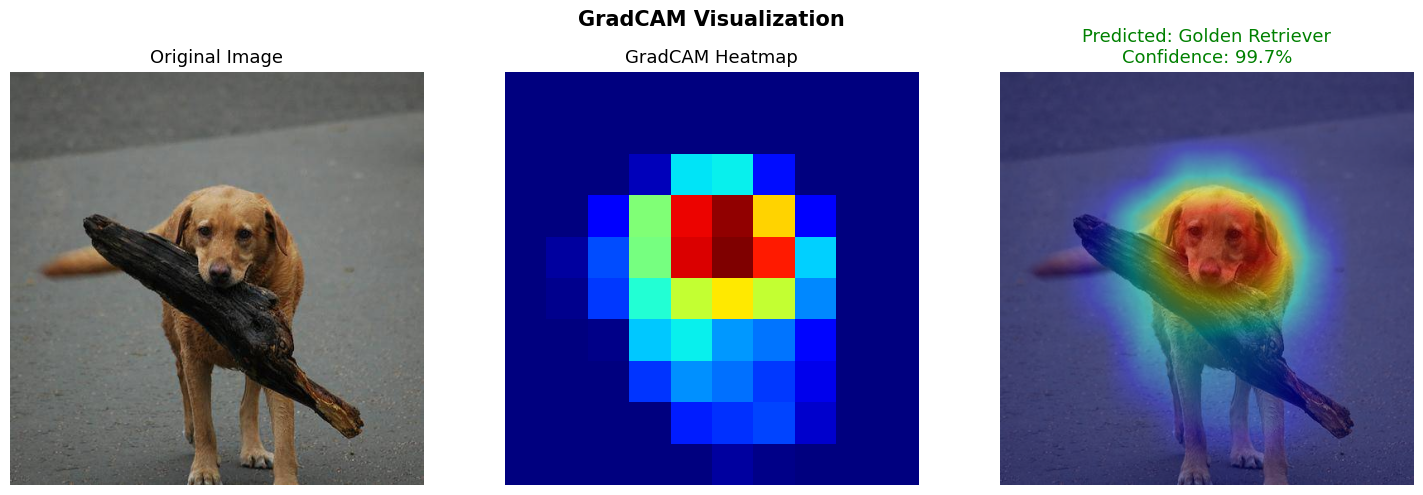


🐶 Predicted Breed : Golden Retriever
   Confidence      : 99.7%
✅ Result saved as gradcam_result.png


In [9]:
from torchvision import transforms

def predict_and_visualize(image_path):
    # Load image
    image = Image.open(image_path).convert("RGB")

    # Preprocess
    transform = transforms.Compose([
        transforms.Resize((300, 300)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                            [0.229, 0.224, 0.225])
    ])

    input_tensor = transform(image).unsqueeze(0).to(device)
    input_tensor.requires_grad_()

    # Predict
    with torch.enable_grad():
        output     = model(input_tensor)
        probs      = torch.softmax(output, dim=1)[0]
        pred_idx   = probs.argmax().item()
        confidence = probs[pred_idx].item() * 100
        breed      = CLASS_NAMES[pred_idx]

    # Generate GradCAM
    gradcam = GradCAM(model)
    heatmap = gradcam.generate(input_tensor, pred_idx)

    # Overlay heatmap
    overlaid = overlay_heatmap(image, heatmap)

    # ---- Plot results ----
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Original image
    axes[0].imshow(image)
    axes[0].set_title("Original Image", fontsize=13)
    axes[0].axis("off")

    # Heatmap only
    axes[1].imshow(heatmap, cmap="jet")
    axes[1].set_title("GradCAM Heatmap", fontsize=13)
    axes[1].axis("off")

    # Overlaid
    axes[2].imshow(overlaid)
    axes[2].set_title(f"Predicted: {breed}\nConfidence: {confidence:.1f}%",
                    fontsize=13, color="green")
    axes[2].axis("off")

    plt.suptitle("GradCAM Visualization", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.savefig("gradcam_result.png", dpi=150)
    plt.show()

    print(f"\n🐶 Predicted Breed : {breed}")
    print(f"   Confidence      : {confidence:.1f}%")
    print(f"✅ Result saved as gradcam_result.png")


predict_and_visualize("test_dog.jpg")